In [1]:
# --- IMPORT LIBRARY ---
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50 # Ganti ke ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

from tensorflow.keras.regularizers import l2


In [ ]:
# --- 1. SETUP GPU RTX 3050 ---
print("🔍 Memeriksa GPU...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU RTX 3050 Terdeteksi! Siap Training.")
        
        # ResNet50 sedikit lebih ringan dari EfficientNetV2-S di memori, 
        BATCH_SIZE = 4 
        print(f"ℹ️ Mengatur BATCH_SIZE = {BATCH_SIZE}.")
        
    except RuntimeError as e:
        print(e)
else:
    BATCH_SIZE = 8

# --- KONFIGURASI ---
DATA_DIR = "Rice_Leaf_AUG_split"
IMG_SIZE = (224, 224)
EPOCHS = 30 
START_LR = 0.0001

🔍 Memeriksa GPU...
✅ GPU RTX 3050 Terdeteksi! Siap Training.
ℹ️ Mengatur BATCH_SIZE = 4.


In [4]:
# --- 2. PERSIAPAN DATA ---
# Menggunakan augmentasi on-the-fly sesuai konfigurasi lama (bukan buku)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("\n📂 Memuat Data Generator...")
if not os.path.exists(DATA_DIR):
    print("❌ Error: Folder dataset tidak ditemukan.")
else:
    # Train Generator
    train_gen = train_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'train'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )

    # Val Generator
    val_gen = val_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'val'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    # Test Generator (Shuffle False agar urutan prediksi benar)
    test_gen = test_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'test'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False 
    )

    NUM_CLASSES = len(train_gen.class_indices)
    CLASS_NAMES = list(train_gen.class_indices.keys())


📂 Memuat Data Generator...
Found 1797 images belonging to 4 classes.
Found 512 images belonging to 4 classes.
Found 260 images belonging to 4 classes.



📊 Menampilkan Distribusi Data...


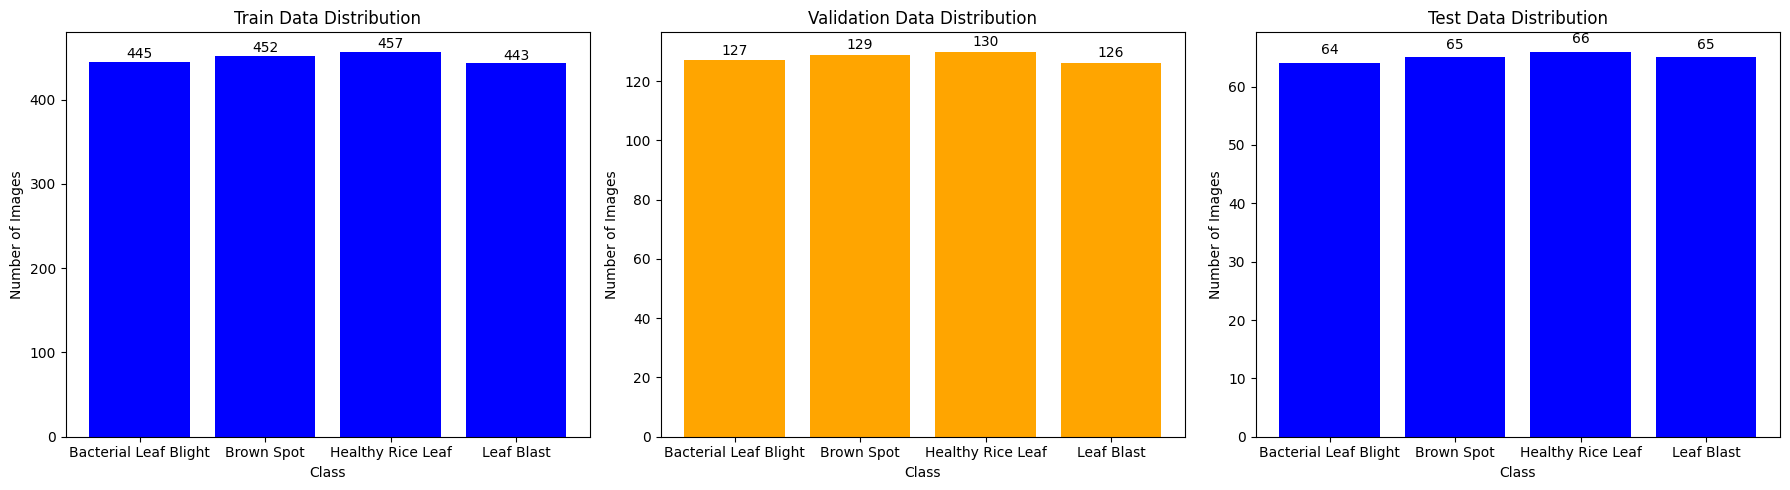

In [5]:
# --- 3. VISUALISASI DISTRIBUSI DATA ---
def plot_distribution(generator, title, color):
    class_counts = np.zeros(NUM_CLASSES)
    for cls_idx in generator.classes:
        class_counts[cls_idx] += 1
        
    plt.bar(CLASS_NAMES, class_counts, color=color)
    plt.title(title)
    plt.ylabel('Number of Images')
    plt.xlabel('Class')
    plt.xticks(rotation=0)
    
    for i, count in enumerate(class_counts):
        plt.text(i, count + 1, str(int(count)), ha='center', va='bottom')

if 'train_gen' in locals():
    print("\n📊 Menampilkan Distribusi Data...")
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1); plot_distribution(train_gen, 'Train Data Distribution', 'blue')
    plt.subplot(1, 3, 2); plot_distribution(val_gen, 'Validation Data Distribution', 'orange')
    plt.subplot(1, 3, 3); plot_distribution(test_gen, 'Test Data Distribution', 'blue')
    plt.tight_layout(); plt.show()

In [6]:
# --- 4. BUILD MODEL RESNET50 ---
def build_model():
    print("\n🏗️ Membangun Arsitektur ResNet50...")
    # Load ResNet50 Base
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    
    # Unfreeze agar belajar
    base_model.trainable = True 
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x) # Dropout agak besar untuk ResNet biar ga overfitting
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=START_LR),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [7]:
# --- 5. TRAINING ---
model = build_model()

# Callbacks (Simpan dengan nama beda: resnet50_best.h5)
checkpoint = ModelCheckpoint('resnet50_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("\n🚀 Mulai Training ResNet50...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[checkpoint, reduce_lr, early_stop]
)


🏗️ Membangun Arsitektur ResNet50...

🚀 Mulai Training ResNet50...
Epoch 1/30
450/450 [==============================] - ETA: 0s - loss: 1.3627 - accuracy: 0.5498
Epoch 1: val_accuracy improved from -inf to 0.24609, saving model to resnet50_best.h5
450/450 [==============================] - 69s 124ms/step - loss: 1.3627 - accuracy: 0.5498 - val_loss: 5.6210 - val_accuracy: 0.2461 - lr: 1.0000e-04
Epoch 2/30
450/450 [==============================] - ETA: 0s - loss: 1.0424 - accuracy: 0.6717
Epoch 2: val_accuracy improved from 0.24609 to 0.37695, saving model to resnet50_best.h5
450/450 [==============================] - 51s 114ms/step - loss: 1.0424 - accuracy: 0.6717 - val_loss: 4.2130 - val_accuracy: 0.3770 - lr: 1.0000e-04
Epoch 3/30
450/450 [==============================] - ETA: 0s - loss: 0.9721 - accuracy: 0.6822
Epoch 3: val_accuracy improved from 0.37695 to 0.81055, saving model to resnet50_best.h5
450/450 [==============================] - 41s 90ms/step - loss: 0.9721 - accur


📈 Menampilkan Grafik Training...


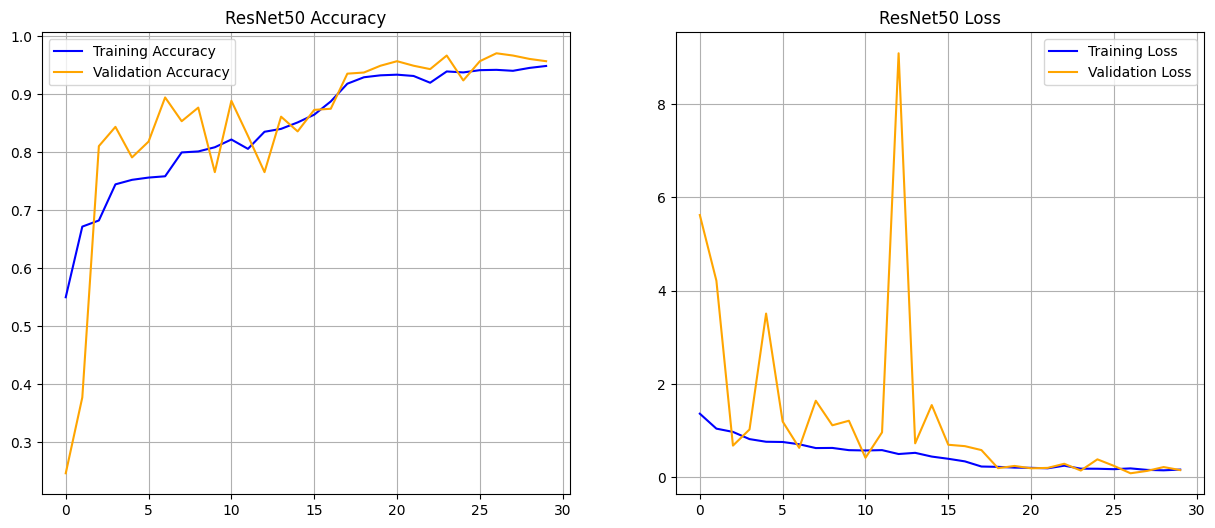

In [11]:
# --- 6. VISUALISASI HISTORY ---
if 'history' in locals():
    print("\n📈 Menampilkan Grafik Training...")
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
    plt.title('ResNet50 Accuracy')
    plt.legend(loc='upper left'); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
    plt.title('ResNet50 Loss')
    plt.legend(loc='upper right'); plt.grid(True)
    plt.show()


🔍 Evaluasi Detail pada Data Test...
65/65 [==============================] - 3s 40ms/step


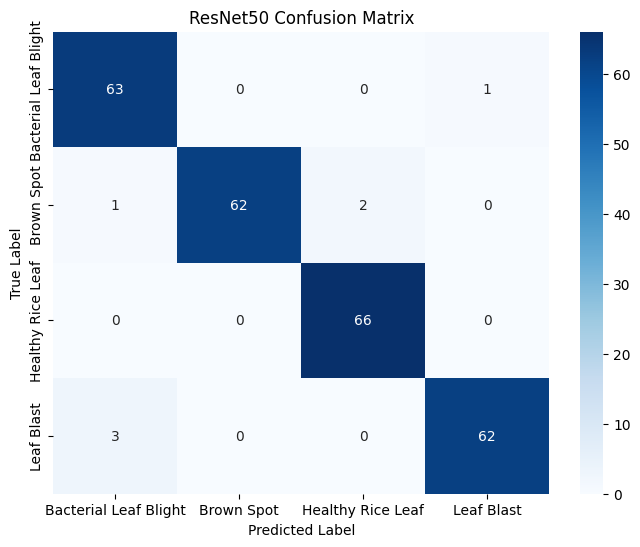


📄 Classification Report:
                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.94      0.98      0.96        64
           Brown Spot       1.00      0.95      0.98        65
    Healthy Rice Leaf       0.97      1.00      0.99        66
           Leaf Blast       0.98      0.95      0.97        65

             accuracy                           0.97       260
            macro avg       0.97      0.97      0.97       260
         weighted avg       0.97      0.97      0.97       260



In [12]:
# --- 7. EVALUASI & CONFUSION MATRIX ---
print("\n🔍 Evaluasi Detail pada Data Test...")
predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('ResNet50 Confusion Matrix')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.show()

# Report
print("\n📄 Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


🖼️ Sampel Prediksi ResNet50...
Found 260 images belonging to 4 classes.
1/1 [==============================] - 1s 889ms/step


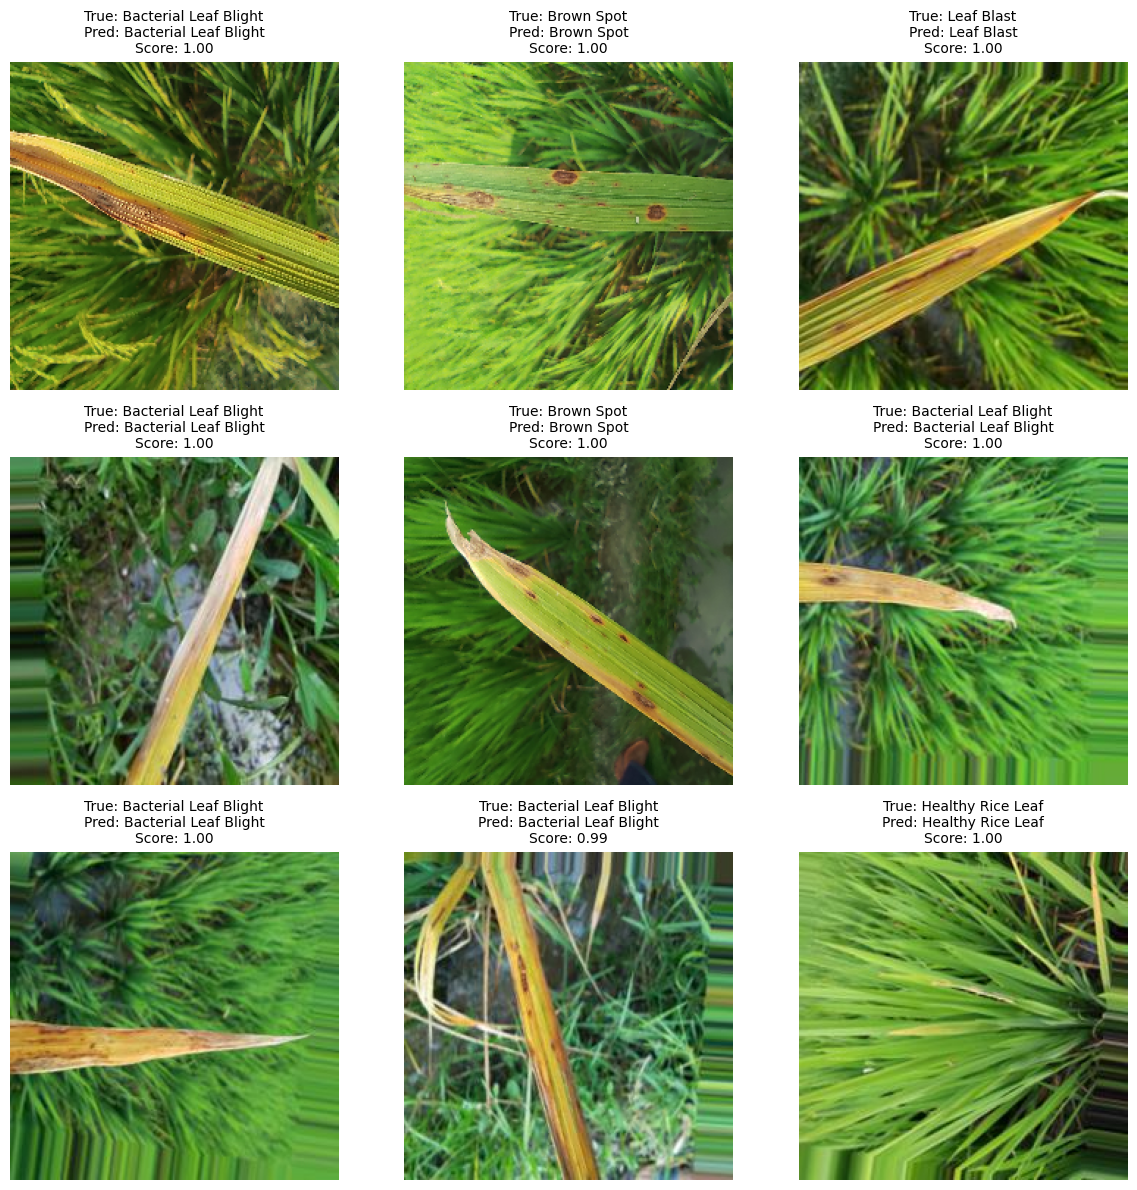


✅ ResNet50 Selesai! Model tersimpan sebagai 'resnet50_best.h5'


In [ ]:
# --- 8. SAMPEL PREDIKSI ---
print("\n🖼️ Sampel Prediksi ResNet50...")
sample_gen = test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=9,
    class_mode='categorical',
    shuffle=True 
)

images, labels = next(sample_gen)
preds = model.predict(images)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    true_name = CLASS_NAMES[true_labels[i]]
    pred_name = CLASS_NAMES[pred_labels[i]]
    score = np.max(preds[i])
    
    title_color = 'black' if true_name == pred_name else 'red'
    plt.title(f"True: {true_name}\nPred: {pred_name}\nScore: {score:.2f}", 
              color=title_color, fontsize=10)
    plt.axis('off')

plt.tight_layout(); plt.show()

print("\n✅ ResNet50 Selesai! Model tersimpan sebagai 'resnet50_best.h5'")